# 03 – Rule engine (R01–R09)

**Mục tiêu:** kiểm tra giao dịch theo 9 quy tắc nghiệp vụ trong bản phân tích. Đây là các điều kiện xác định được bằng logic nên **không dùng AI**: kết quả chính xác, giải thích được và lần chạy nào cũng giống nhau.

**Thành phần**
| File | Vai trò |
|---|---|
| `src/rules.py` | Cài đặt 9 rule và hàm xếp mức rủi ro |
| `config/rules.toml` | Các ngưỡng (hạn mức, số ngày, danh sách loại trừ…), sửa được mà không cần sửa code |
| `data/reference/budgets.csv` | Ngân sách tháng theo đơn vị × nhóm chi phí (tự sinh, `scripts/build_reference_data.py`) |
| `data/reference/approved_merchants.csv` | Danh sách cửa hàng "đã duyệt" (xuất hiện trong 07–12/2025) |
| `tests/test_rules.py` | 16 kiểm thử tự động cho từng rule |

Mỗi vi phạm được ghi lại dưới dạng: `txn_id | rule_id | severity | message | related_txn_ids`. Phần `message` bằng tiếng Việt, có số liệu cụ thể, và sẽ là đầu vào cho LLM ở bước giải thích.

In [1]:
import sys, time, copy
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_pcard
from src.labels import add_expense_group, GROUPS
from src.rules import run_rules, risk_level, load_config, load_reference, RULE_NAMES

pd.set_option('display.width', 180); pd.set_option('display.max_colwidth', 120)
BLUE, ORANGE, INK, INK2, GRID = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'font.family': ['Arial', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': INK2, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'figure.dpi': 110, 'figure.facecolor': 'white',
})

## 1. Cấu hình đang dùng

In [2]:
cfg = load_config()
pd.DataFrame([(k, RULE_NAMES[k], {kk: vv for kk, vv in v.items()}) for k, v in cfg.items()],
             columns=['Mã', 'Quy tắc', 'Tham số']).set_index('Mã')

,Quy tắc,Tham số
Mã,,
R01,Thiếu chứng từ / mô tả,"{'min_amount': 1000, 'severity': 'Trung bình'}"
R02,Vượt hạn mức phê duyệt,"{'limit': 5000, 'severity': 'Cao'}"
R03,Trùng hóa đơn,"{'window_days': 3, 'min_amount': 100, 'exclude_item_desc': ['ROOM CHARGES', 'AIR TRAVEL'], 'exclude_groups': ['LODGI..."
R04,Chia nhỏ giao dịch,"{'limit': 5000, 'window_days': 3, 'min_each': 1000, 'severity': 'Cao'}"
R05,Vượt ngân sách,"{'warn_ratio': 0.9, 'severity_warn': 'Thấp', 'severity_over': 'Cao', 'severity_after': 'Thấp'}"
R06,Giao dịch tương đương tiền mặt,"{'mcc': ['WIRE TRANSFER MONEY ORDERS', 'POI FUNDING TRANSACTIONS EXCLUDING MONEYSEND'], 'severity': 'Trung bình'}"
R07,Cửa hàng chưa được duyệt,"{'start_month': '2026-01', 'min_amount': 500, 'severity': 'Trung bình'}"
R08,Loại chi phí không được phép,"{'banned_mcc_pattern': 'PACKAGE STORES|DRINKING PLACES|CIGAR|MASSAGE|JEWELRY|PRECIOUS STONES|BETTING|GAMBLING', 'sev..."
R09,Giao dịch ngày nghỉ,"{'include_holidays': True, 'severity': 'Thấp'}"


## 2. Chạy trên toàn bộ dữ liệu

In [3]:
df = add_expense_group(load_pcard())
budgets, approved = load_reference()
print(f'Giao dịch: {len(df):,} | Ngân sách: {len(budgets):,} dòng | Cửa hàng đã duyệt: {len(approved):,}')

t0 = time.time()
hits = run_rules(df, cfg, budgets=budgets, approved=approved)
df['risk_level'] = risk_level(df, hits)
print(f'Thời gian chạy 9 rule: {time.time() - t0:.1f} giây | Số vi phạm: {len(hits):,}')

Giao dịch: 485,616 | Ngân sách: 12,446 dòng | Cửa hàng đã duyệt: 19,098


Thời gian chạy 9 rule: 7.9 giây | Số vi phạm: 144,227


In [4]:
summary = hits.groupby(['rule_id', 'severity']).size().unstack(fill_value=0)
summary = summary.reindex(columns=['Cao', 'Trung bình', 'Thấp'], fill_value=0)
summary.insert(0, 'Quy tắc', summary.index.map(RULE_NAMES))
summary['% giao dịch'] = hits.groupby('rule_id').txn_id.nunique() / len(df)
summary.style.format({'% giao dịch': '{:.2%}', 'Cao': '{:,}', 'Trung bình': '{:,}', 'Thấp': '{:,}'})

severity,Quy tắc,Cao,Trung bình,Thấp,% giao dịch
rule_id,,,,,
R01,Thiếu chứng từ / mô tả,0,"18,731",0,3.86%
R02,Vượt hạn mức phê duyệt,"3,906",0,0,0.80%
R03,Trùng hóa đơn,"6,157",0,0,1.27%
R04,Chia nhỏ giao dịch,"3,065",0,0,0.63%
R05,Vượt ngân sách,"4,273",0,"43,629",9.86%
R06,Giao dịch tương đương tiền mặt,0,170,0,0.04%
R07,Cửa hàng chưa được duyệt,0,"8,765",0,1.80%
R08,Loại chi phí không được phép,375,184,0,0.12%
R09,Giao dịch ngày nghỉ,0,0,"54,972",11.32%


risk_level
Bình thường     92.1%
Cần review       4.4%
Cảnh báo cao     3.5%


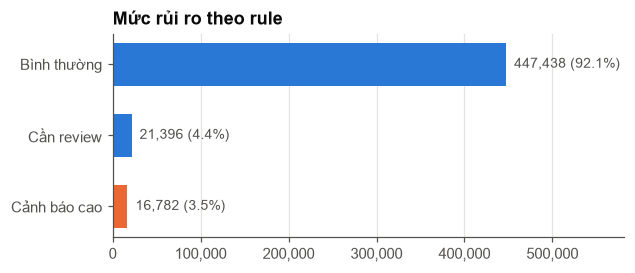

In [5]:
levels = df.risk_level.value_counts().reindex(['Bình thường', 'Cần review', 'Cảnh báo cao'])
print((levels / len(df)).map('{:.1%}'.format).to_string())
fig, ax = plt.subplots(figsize=(6, 2.4))
ax.barh(levels.index[::-1], levels.values[::-1], color=[ORANGE, BLUE, BLUE], height=0.6)
for i, v in enumerate(levels.values[::-1]):
    ax.text(v, i, f'  {v:,} ({v / len(df):.1%})', va='center', fontsize=9, color=INK2)
ax.set_title('Mức rủi ro theo rule'); ax.grid(axis='y', visible=False); ax.set_xlim(0, levels.max() * 1.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

**Nhận xét:**
- Với cấu hình đã tinh chỉnh, khoảng **8% giao dịch cần người xem** (Cần review + Cảnh báo cao), tương đương vài nghìn giao dịch mỗi tháng trên toàn bang. Đây là khối lượng kiểm tra được.
- Rule mức Thấp (R09 ngày nghỉ, R05 khi đã vượt ngân sách) chỉ được ghi chú. Chúng không tự làm thay đổi mức rủi ro, nhưng vẫn là thông tin cho LLM giải thích và cho mô hình bất thường.

## 3. Tác động của việc tinh chỉnh ngưỡng

So sánh cùng bộ rule với cấu hình "lỏng" (điều kiện ban đầu, chưa dựa trên dữ liệu) và cấu hình đã tinh chỉnh sau khi khám phá dữ liệu.

In [6]:
naive = copy.deepcopy(cfg)
naive['R01']['min_amount'] = 0                                    # mọi mô tả chung chung
naive['R03'].update(min_amount=0, exclude_item_desc=[], exclude_groups=[])  # không loại tiền phòng / vé máy bay
naive['R04'].update(window_days=7, min_each=0)                    # cửa sổ 7 ngày, mọi khoản
naive['R05']['severity_after'] = 'Trung bình'                     # mọi giao dịch sau khi vượt ngân sách
naive['R07']['min_amount'] = 0
naive['R08']['severity_casino'] = 'Cao'                           # khách sạn casino coi như vi phạm

t0 = time.time()
hits_naive = run_rules(df, naive, budgets=budgets, approved=approved)
level_naive = risk_level(df, hits_naive)
print(f'{time.time() - t0:.1f} giây')

cmp = pd.DataFrame({
    'Quy tắc': pd.Series(RULE_NAMES),
    'Lỏng': hits_naive.groupby('rule_id').txn_id.nunique() / len(df),
    'Tinh chỉnh': hits.groupby('rule_id').txn_id.nunique() / len(df),
}).fillna(0)
cmp.style.format({'Lỏng': '{:.2%}', 'Tinh chỉnh': '{:.2%}'})

38.4 giây


,Quy tắc,Lỏng,Tinh chỉnh
R01,Thiếu chứng từ / mô tả,37.66%,3.86%
R02,Vượt hạn mức phê duyệt,0.80%,0.80%
R03,Trùng hóa đơn,9.17%,1.27%
R04,Chia nhỏ giao dịch,3.79%,0.63%
R05,Vượt ngân sách,9.86%,9.86%
R06,Giao dịch tương đương tiền mặt,0.04%,0.04%
R07,Cửa hàng chưa được duyệt,5.76%,1.80%
R08,Loại chi phí không được phép,0.12%,0.12%
R09,Giao dịch ngày nghỉ,11.32%,11.32%


In [7]:
pd.DataFrame({
    'Lỏng': level_naive.value_counts(normalize=True),
    'Tinh chỉnh': df.risk_level.value_counts(normalize=True),
}).reindex(['Bình thường', 'Cần review', 'Cảnh báo cao']).style.format('{:.1%}')

,Lỏng,Tinh chỉnh
Bình thường,47.0%,92.1%
Cần review,39.4%,4.4%
Cảnh báo cao,13.6%,3.5%


**Nhận xét:** với cấu hình lỏng, **hơn một nửa giao dịch (khoảng 53%)** phải đưa cho người xem, phần lớn là cảnh báo giả: tiền phòng theo đêm, vé máy bay đoàn, mọi giao dịch trong tháng đã vượt ngân sách, lưu trú ở khách sạn casino. Tinh chỉnh ngưỡng dựa trên dữ liệu thật giảm khối lượng này xuống còn khoảng 8% mà vẫn giữ các vi phạm rõ ràng (vượt hạn mức, chia nhỏ, danh mục cấm).

## 4. Ví dụ từng rule

In [8]:
view = df.set_index('txn_id')[['tx_date', 'agency', 'merchant', 'item_desc', 'amount']]
examples = hits.sort_values(['rule_id', 'severity']).groupby(['rule_id', 'severity']).sample(1, random_state=1)
examples.join(view, on='txn_id')[['rule_id', 'severity', 'tx_date', 'merchant', 'item_desc', 'amount', 'message']] \
    .style.format({'amount': '${:,.2f}', 'tx_date': '{:%d/%m/%Y}'}).hide(axis='index')

rule_id,severity,tx_date,merchant,item_desc,amount,message
R01,Trung bình,20/08/2025,Frontiers Media SA,GENERAL PURCHASE,"$2,081.15","Khoản chi $2,081.15 (≥ $1,000.00) nhưng mô tả mặt hàng chung chung, không rõ đã mua gì."
R02,Cao,30/04/2026,STAPLES,PEN BP RSVP MED BLACK DZ,"$9,792.00","Số tiền $9,792.00 vượt hạn mức $5,000.00 cho một giao dịch."
R03,Cao,21/04/2026,THEBIGSKYLITERACYSUMMI,The Big Sky Literacy Summi each,$895.00,"Trùng người chi, cửa hàng và số tiền $895.00 với giao dịch 202604-015649 trong cùng ngày."
R04,Cao,07/08/2025,IN GNC ELECTRICAL ENTERP,GENERAL PURCHASE,"$1,114.45","3 giao dịch cùng người chi tại cùng cửa hàng trong 3 ngày, mỗi khoản dưới hạn mức nhưng tổng $7,468.16 vượt hạn mức $5,000.00."
R05,Cao,10/12/2025,NATUS SENSORY INC,Invoice Payment Inv,"$16,984.83","Giao dịch làm lũy kế chi $20,261.75 vượt ngân sách tháng $8,350.00 (243%)."
R05,Thấp,27/01/2026,UNITED 0167363594480,AIR TRAVEL,$201.48,"Phát sinh thêm khi nhóm chi phí đã vượt ngân sách tháng $375,910.00 (lũy kế $443,811.95, 118%)."
R06,Trung bình,12/08/2025,CS QUIKTRIP GC,GENERAL PURCHASE,$30.00,"Giao dịch thuộc loại chuyển tiền/nạp tiền (POI FUNDING TRANSACTIONS EXCLUDING MONEYSEND), tương đương rút tiền mặt."
R07,Trung bình,08/07/2026,PAYPAL GOATAMOVEME,PAYMENT TO GOATA MOVEMENT ITM,"$1,039.84","Cửa hàng ""PAYPAL GOATAMOVEME"" chưa có trong danh sách nhà cung cấp đã duyệt."
R08,Cao,28/11/2025,BUFFALO WILD WNGS 3786,GENERAL PURCHASE,$424.62,Loại hình cửa hàng thuộc danh mục không được phép chi: DRINKING PLACES (ALCOHOLIC BEV.)-BARS TA.
R08,Trung bình,11/09/2025,CAESAR S PALACE DEPOSIT,ROOM CHARGES,$339.01,Chi tại cơ sở có casino (CAESARS HOTEL AND CASINO); cần xác nhận là chi phí lưu trú công tác.


## 5. Một giao dịch vi phạm nhiều rule

Đây là dạng đầu vào sẽ đưa cho LLM ở bước giải thích: thông tin giao dịch kèm danh sách vi phạm có số liệu. LLM không tự kiểm tra lại điều kiện, mà chỉ diễn giải và gợi ý việc cần làm.

In [9]:
n_rules = hits.groupby('txn_id').rule_id.nunique()
worst = df[df.risk_level == 'Cảnh báo cao'].set_index('txn_id').join(n_rules.rename('n_rules')).sort_values(['n_rules', 'amount'], ascending=False)
txn = worst.index[0]
print(view.loc[txn].to_string(), '\n')
hits[hits.txn_id == txn][['rule_id', 'severity', 'message', 'related_txn_ids']]

tx_date                        2026-04-21 00:00:00
agency       UNIV. OF OKLA. HEALTH SCIENCES CENTER
merchant                       CMS DATA RQST PYMNT
item_desc                         GENERAL PURCHASE
amount                                     24999.0 



,rule_id,severity,message,related_txn_ids
12852,R01,Trung bình,"Khoản chi $24,999.00 (≥ $1,000.00) nhưng mô tả mặt hàng chung chung, không rõ đã mua gì.",
21253,R02,Cao,"Số tiền $24,999.00 vượt hạn mức $5,000.00 cho một giao dịch.",
27047,R03,Cao,"Trùng người chi, cửa hàng và số tiền $24,999.00 với giao dịch 202604-033936 cách 1 ngày.",202604-033936
61793,R05,Thấp,"Phát sinh thêm khi nhóm chi phí đã vượt ngân sách tháng $57,900.00 (lũy kế $118,963.70, 205%).",
83900,R07,Trung bình,"Cửa hàng ""CMS DATA RQST"" chưa có trong danh sách nhà cung cấp đã duyệt.",


In [10]:
print('Số giao dịch theo số rule vi phạm (mức Trung bình trở lên):')
serious = hits[hits.severity != 'Thấp']
serious.groupby('txn_id').rule_id.nunique().value_counts().sort_index().rename('Số giao dịch').to_frame()

Số giao dịch theo số rule vi phạm (mức Trung bình trở lên):


,Số giao dịch
rule_id,
1,31598
2,5766
3,762
4,50
5,2


## 6. Lưu kết quả

In [11]:
out = ROOT / 'data' / 'processed'
out.mkdir(exist_ok=True)
hits.to_csv(out / 'rule_hits.csv', index=False)
df[['txn_id', 'risk_level']].to_csv(out / 'rule_risk.csv', index=False)
for f in sorted(out.glob('rule_*.csv')):
    print(f.name, f'{f.stat().st_size / 1e6:.1f} MB')

rule_hits.csv 17.8 MB
rule_risk.csv 15.0 MB


## 7. Kết luận

1. Rule engine chạy hết 485 nghìn giao dịch trong vài giây, có 16 kiểm thử tự động. Ngưỡng nằm trong file cấu hình, thay đổi được mà không cần sửa code.
2. **Tinh chỉnh ngưỡng trên dữ liệu thật** giảm tỷ lệ giao dịch phải xem từ khoảng 53% xuống khoảng 8%. Đây là minh chứng cho việc rule phải được thiết kế dựa trên dữ liệu, không thể đặt máy móc.
3. **Rule chỉ phát hiện được những gì đã định nghĩa trước.** Các dấu hiệu như "số tiền bất thường so với thói quen của người chi" thì rule không bắt được. Đó là việc của mô hình phát hiện bất thường (bước tiếp theo).
4. **Kết quả rule** (mã rule, mức độ, thông báo có số liệu, giao dịch liên quan) là đầu vào có cấu trúc cho LLM. LLM chỉ giải thích và đề xuất, không thay đổi kết luận của rule.